# Evolución de 2024, 2025 y 2026

Este notebook analiza los tres años descargados al mismo tiempo, como pide el Ejercicio 8. Usa la tabla `trips` de
`data/processed/taxi.duckdb`, que crea `scripts/create_database.py`. Para las columnas que no están en esa tabla consulta
directamente los archivos Parquet de `data/raw/`. Los indicadores del tablero se leen de `sql/indicators/`, entonces el
notebook y el tablero usan exactamente las mismas consultas.

Hay dos cuidados que se tienen en todo el análisis. El primero es que 2026 solo tiene los meses que la TLC ya publicó
(enero a agosto en este momento), entonces las comparaciones entre años usan solo los meses que existen en los tres años.
El segundo es que los promedios usan solo viajes válidos, que son los que tienen una distancia entre 0 y 100 millas, una
tarifa entre 0 y 1,000 dólares y una duración entre 0 y 24 horas.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

RAIZ = next(p for p in (Path("."), Path("..")) if (p / "data/processed/taxi.duckdb").exists())
sys.path.insert(0, str(RAIZ / "scripts"))
from indicators import cargar_indicadores

con = duckdb.connect(str(RAIZ / "data/processed/taxi.duckdb"), read_only=True)
INDICADORES = {i.nombre: i for i in cargar_indicadores(RAIZ / "sql/indicators")}

COLOR_TIPO = {"yellow": "#eda100", "green": "#008300"}
COLOR_ANIO = {2024: "#2a78d6", 2025: "#eb6834", 2026: "#1baf7a"}
VALIDO = ("trip_distance > 0 AND trip_distance < 100 AND fare_amount > 0 AND fare_amount < 1000 "
          "AND duration_minutes > 0 AND duration_minutes < 1440")
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})

def q(sql):
    return con.execute(sql).fetchdf()

def indicador(nombre):
    return q(INDICADORES[nombre].sql)

q("SELECT taxi_type, year, count(*) AS viajes, min(month) AS mes_min, max(month) AS mes_max FROM trips GROUP BY ALL ORDER BY ALL")

,taxi_type,year,viajes,mes_min,mes_max
0,green,2024,660218,1,12
1,green,2025,591375,1,12
2,green,2026,337114,1,8
3,yellow,2024,41169720,1,12
4,yellow,2025,48722602,1,12
5,yellow,2026,29703355,1,8


## 1. Cantidad de viajes, con su punto más alto en 2025

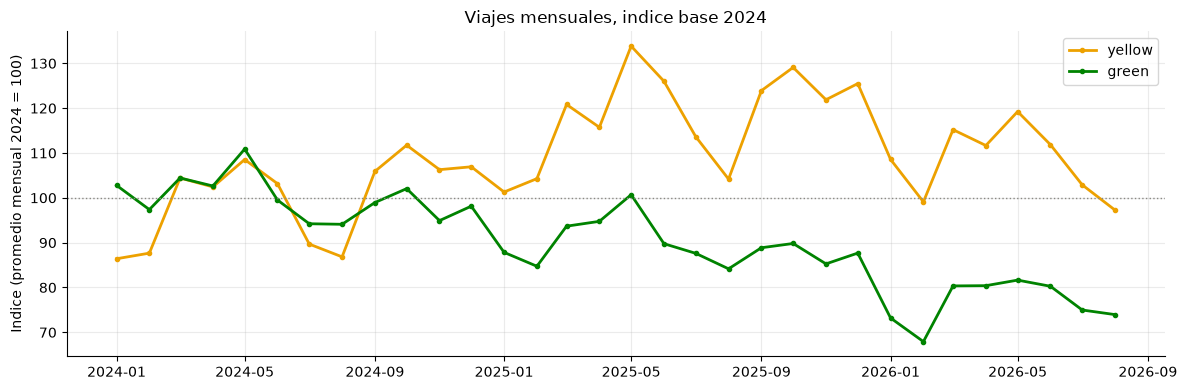

,year,pct_green
0,2024,1.58
1,2025,1.20
2,2026,1.12


,tipo,anio,meses,viajes,cambio_viajes_pct,tarifa_promedio_usd,distancia_promedio_millas,duracion_promedio_min,propina_pct_tarifa_tarjeta
0,yellow,2024,1-8,26388179,NaN,19.54,3.42,17.1,22.0
1,yellow,2025,1-8,31556438,19.6,19.58,3.45,16.9,22.2
2,yellow,2026,1-8,29703355,-5.9,21.30,3.52,17.9,21.5
3,green,2024,1-8,443415,NaN,17.88,2.93,19.2,19.5
4,green,2025,1-8,397918,-10.3,18.02,3.11,21.3,19.6
5,green,2026,1-8,337114,-15.3,17.16,3.31,21.1,20.9


In [2]:
# Indice base 100 = promedio mensual de 2024 de cada tipo: permite ver yellow y green en un solo eje
# aunque green sea ~1 % del volumen (en vez de un grafico con dos escalas).
mensual = q("""
SELECT make_date(year, month, 1) AS periodo, taxi_type, count(*) AS viajes
FROM trips GROUP BY ALL ORDER BY ALL""")
base = mensual[mensual.periodo.dt.year == 2024].groupby("taxi_type").viajes.mean()
mensual["indice"] = mensual.viajes / mensual.taxi_type.map(base) * 100

fig, eje = plt.subplots(figsize=(12, 4))
for tipo, color in COLOR_TIPO.items():
    d = mensual[mensual.taxi_type == tipo]
    eje.plot(d.periodo, d.indice, color=color, marker="o", markersize=3, label=tipo)
eje.axhline(100, color="#8a8984", linewidth=1, linestyle=":")
eje.set_ylabel("Indice (promedio mensual 2024 = 100)"); eje.set_title("Viajes mensuales, indice base 2024"); eje.legend()
plt.tight_layout(); plt.show()

participacion = q("SELECT year, round(100.0 * count_if(taxi_type = 'green') / count(*), 2) AS pct_green FROM trips GROUP BY year ORDER BY year")
display(participacion)
indicador("07_comparacion_anual")

### Qué muestra

La gráfica usa un índice para poder poner yellow y green en la misma escala. El índice vale 100 en el promedio mensual de
2024 de cada servicio, así que un valor de 120 significa 20 % más viajes que en 2024 y uno de 80 significa 20 % menos.

En los meses comunes (enero a agosto), yellow crece 19.6 % de 2024 a 2025 y baja 5.9 % en 2026, aunque aun así queda 12.6 %
por encima de 2024. Green baja en los dos años (10.3 % y 15.3 %) y su índice termina cerca de 75. La parte de green en el
total de viajes baja de 1.58 % en 2024 a 1.20 % en 2025 y a 1.12 % en 2026. Si solo se miraran 2024 y 2026, parecería que
yellow crece sin parar. El año del medio muestra que 2025 fue el punto más alto y que en 2026 la tendencia cambió de
dirección.

## 2. El precio sube de golpe en diciembre de 2025

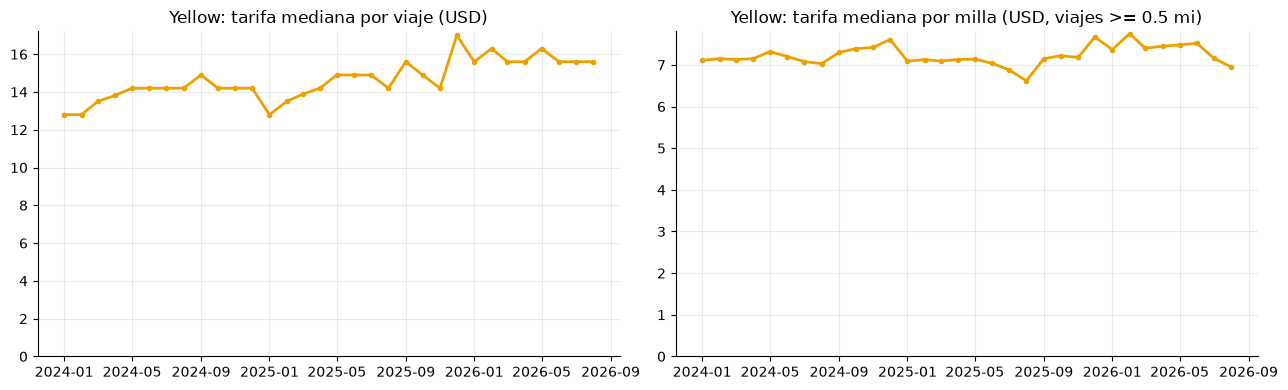

,periodo,tarifa_mediana,usd_por_milla_mediana
20,2025-09-01,15.6,7.15
21,2025-10-01,14.9,7.22
22,2025-11-01,14.2,7.18
23,2025-12-01,17.0,7.67
24,2026-01-01,15.6,7.37
25,2026-02-01,16.3,7.75
26,2026-03-01,15.6,7.40


In [3]:
precio = q(f"""
SELECT make_date(year, month, 1) AS periodo,
       round(median(fare_amount), 2) AS tarifa_mediana,
       round(median(fare_amount / trip_distance) FILTER (WHERE trip_distance >= 0.5), 2) AS usd_por_milla_mediana
FROM trips WHERE taxi_type = 'yellow' AND {VALIDO}
GROUP BY periodo ORDER BY periodo""")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4))
a.plot(precio.periodo, precio.tarifa_mediana, color=COLOR_TIPO["yellow"], marker="o", markersize=3)
a.set_title("Yellow: tarifa mediana por viaje (USD)"); a.set_ylim(bottom=0)
b.plot(precio.periodo, precio.usd_por_milla_mediana, color=COLOR_TIPO["yellow"], marker="o", markersize=3)
b.set_title("Yellow: tarifa mediana por milla (USD, viajes >= 0.5 mi)"); b.set_ylim(bottom=0)
plt.tight_layout(); plt.show()
precio[(precio.periodo >= "2025-09-01") & (precio.periodo <= "2026-03-01")]

### Qué muestra

La tarifa promedio de yellow sube 8.8 % en 2026, de 19.6 a 21.3 dólares en los meses comunes, y el cambio ocurre en
diciembre de 2025. Ese mes la tarifa mediana pasa de 14.2 dólares (en noviembre) a 17.0 dólares, y el precio mediano por
milla pasa de 7.2 a 7.7 dólares. Durante 2026 el precio por milla se queda entre 7.4 y 7.8 dólares, más alto que en 2024 y
2025. Como sube el precio por milla, el aumento no se explica porque los viajes sean más largos. Puede ser un ajuste de
tarifas, pero los datos no dicen la causa. Green hace lo contrario y su tarifa promedio baja (18.2, 18.0 y 17.2 dólares)
aunque sus viajes son más largos (indicador `08_tarifa_mensual` del tablero).

## 3. Formas de pago, con un salto del pago flexible o sin anotar en 2025

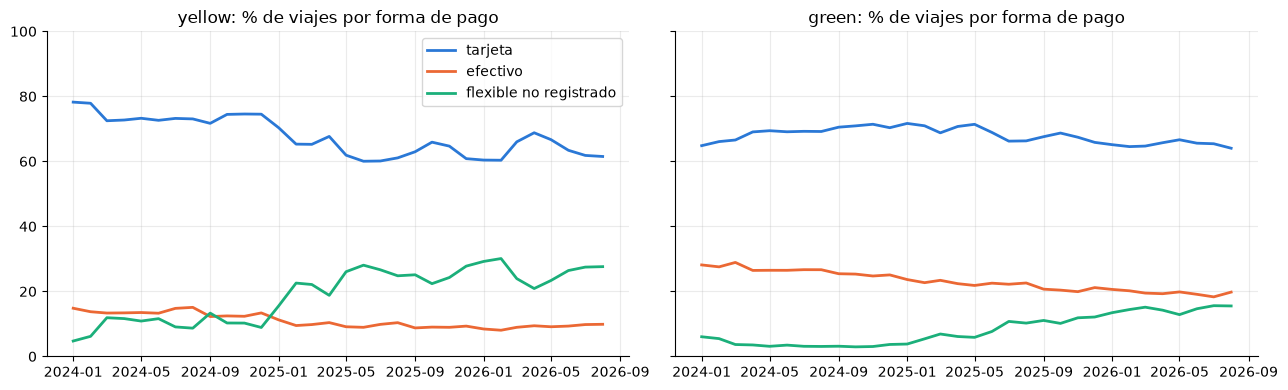

,anio,tipo,propina_pct_tarifa
0,2024,yellow,21.93
1,2024,green,19.46
2,2025,yellow,21.86
3,2025,green,19.83
4,2026,yellow,21.53
5,2026,green,20.93


In [4]:
pagos = q("""
SELECT make_date(year, month, 1) AS periodo, taxi_type,
       100.0 * count_if(payment_type = 1) / count(*) AS tarjeta,
       100.0 * count_if(payment_type = 2) / count(*) AS efectivo,
       100.0 * count_if(payment_type = 0 OR payment_type IS NULL) / count(*) AS flexible_no_registrado
FROM trips GROUP BY ALL ORDER BY ALL""")

fig, ejes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for eje, tipo in zip(ejes, ("yellow", "green")):
    d = pagos[pagos.taxi_type == tipo]
    for columna, color in (("tarjeta", "#2a78d6"), ("efectivo", "#eb6834"), ("flexible_no_registrado", "#1baf7a")):
        eje.plot(d.periodo, d[columna], color=color, label=columna.replace("_", " "))
    eje.set_title(f"{tipo}: % de viajes por forma de pago"); eje.set_ylim(0, 100)
ejes[0].legend()
plt.tight_layout(); plt.show()
indicador("12_propina_tarjeta")

### Qué muestra

En yellow, la categoría `0` (tarifa flexible o pago sin anotar) pasa de cerca de 10 % de los viajes en 2024 a cerca de 24 %
en 2025 y 26 % en 2026. Ese crecimiento sale sobre todo de la tarjeta, que baja de 74 % a 64 %, y del efectivo, que baja de
13.5 % a 9 %. Green va por el mismo camino pero más despacio, con 3.7 %, 8.4 % y 14.5 % de viajes sin forma de pago
anotada. La propina con tarjeta casi no cambia (21.9 %, 21.9 % y 21.5 % de la tarifa en yellow). Los pasajeros siguen
dejando la misma propina, y lo que cambió fue cómo queda anotado el pago.

## 4. Problemas en los datos que dependen de la empresa y del momento

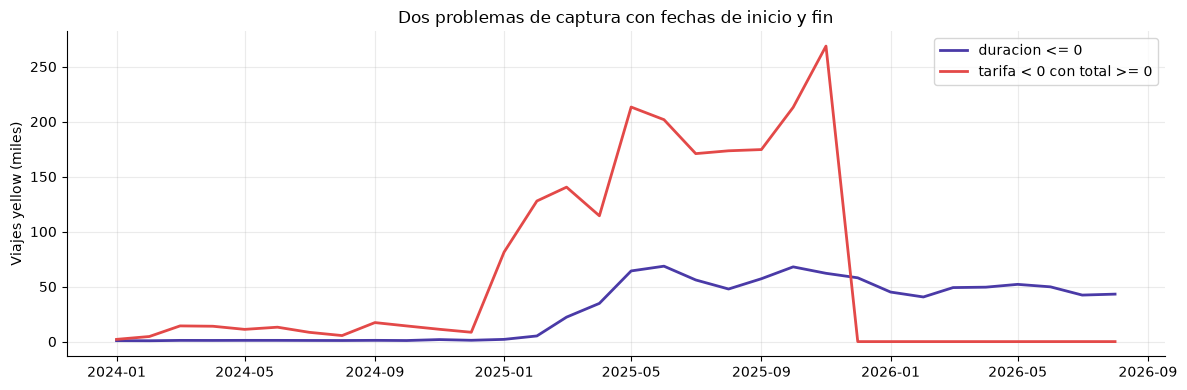

,year,viajes_vendor_7,duracion_no_positiva
0,2024,230,230.0
1,2025,535901,535901.0
2,2026,367120,367120.0


,year,vendor_id,payment_type,viajes,tarifa_promedio,total_promedio
0,2024,2,0,124539,-1.45,2.65
1,2025,2,0,1879872,-4.00,4.30


In [5]:
calidad = q("""
SELECT make_date(year, month, 1) AS periodo,
       count_if(vendor_id = 7) AS viajes_vendor_7,
       count_if(duration_minutes <= 0) AS duracion_no_positiva,
       count_if(fare_amount < 0 AND total_amount >= 0) AS tarifa_negativa_total_positivo
FROM trips WHERE taxi_type = 'yellow' GROUP BY periodo ORDER BY periodo""")

fig, eje = plt.subplots(figsize=(12, 4))
eje.plot(calidad.periodo, calidad.duracion_no_positiva / 1000, color="#4a3aa7", label="duracion <= 0")
eje.plot(calidad.periodo, calidad.tarifa_negativa_total_positivo / 1000, color="#e34948", label="tarifa < 0 con total >= 0")
eje.set_ylabel("Viajes yellow (miles)"); eje.set_title("Dos problemas de captura con fechas de inicio y fin"); eje.legend()
plt.tight_layout(); plt.show()

display(q("""
SELECT year, count(*) AS viajes_vendor_7, count_if(duration_minutes <= 0) AS duracion_no_positiva
FROM trips WHERE taxi_type = 'yellow' AND vendor_id = 7 GROUP BY ALL ORDER BY ALL"""))
q("""
SELECT year, vendor_id, payment_type, count(*) AS viajes,
       round(avg(fare_amount), 2) AS tarifa_promedio, round(avg(total_amount), 2) AS total_promedio
FROM trips WHERE taxi_type = 'yellow' AND fare_amount < 0 AND total_amount >= 0
GROUP BY ALL HAVING count(*) > 1000 ORDER BY year, viajes DESC""")

### Qué muestra

Hay dos problemas que solo se entienden mirando la serie completa.

El primero son las duraciones cero. La empresa con `vendor_id` 7 aparece en diciembre de 2024 con 230 viajes, crece desde
marzo de 2025 y anota todos sus viajes con la misma hora de subida y de bajada. Explica el 98 % de las duraciones cero o
negativas de 2025 y 2026.

El segundo son las tarifas negativas con un total positivo. Son viajes de la empresa con `vendor_id` 2 con `payment_type = 0`
(tarifa flexible), con una tarifa promedio de -4 dólares y un total de 4 dólares. Pasan de 125 mil en 2024 a 1.88 millones
en 2025 y desaparecen en diciembre de 2025 (solo 135 en 2026). Parece ser una forma de anotar que esa empresa usó durante
2025, porque los reembolsos tienen también el total negativo.

Por estos dos casos, el porcentaje de viajes yellow inválidos sube de cerca de 3.5 % a cerca de 10 % durante 2025 y baja a
cerca de 5 % en 2026 (indicador `15_calidad_mensual`). Una regla de limpieza pensada mirando un solo año no habría previsto
ninguno de los dos.

## 5. El peaje de congestión se cobra desde enero de 2025, pero la velocidad en Manhattan no cambia

,periodo,viajes,pct_con_peaje,peaje_promedio_usd
0,2025-01,3475226,64.6,0.75
1,2025-02,3577543,72.7,0.75
2,2025-03,4145257,72.7,0.75
3,2025-04,3970553,72.3,0.75
4,2025-05,4591845,71.5,0.75
5,2025-06,4322960,72.3,0.75
6,2025-07,3898963,72.7,0.75
7,2025-08,3574091,71.9,0.75
8,2025-09,4251015,72.5,0.75
9,2025-10,4428699,72.4,0.75


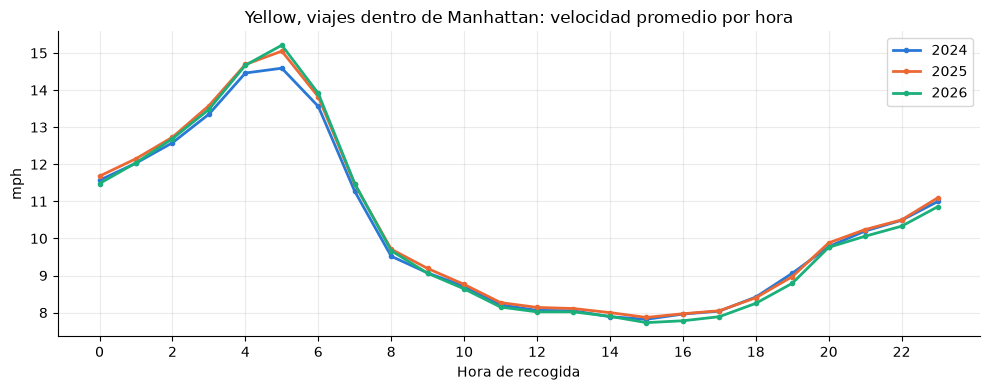

anio
2024    8.62
2025    8.68
2026    8.57
Name: velocidad_mph, dtype: float64

In [6]:
# cbd_congestion_fee no esta en la tabla trips (no existe en los archivos de 2024), asi que se lee
# directamente de los Parquet: DuckDB solo abre las columnas que la consulta usa.
patron = (RAIZ / "data/raw/yellow").as_posix() + "/*/*.parquet"
peaje = q(f"""
SELECT regexp_extract(filename, 'tripdata_(\d{{4}}-\d{{2}})', 1) AS periodo,
       count(*) AS viajes,
       round(100.0 * count_if(cbd_congestion_fee > 0) / count(*), 1) AS pct_con_peaje,
       round(avg(cbd_congestion_fee) FILTER (WHERE cbd_congestion_fee > 0), 2) AS peaje_promedio_usd
FROM read_parquet('{patron}', union_by_name = true, filename = true)
WHERE cbd_congestion_fee IS NOT NULL
GROUP BY periodo ORDER BY periodo""")
display(peaje)

velocidad = indicador("11_velocidad_manhattan")
fig, eje = plt.subplots(figsize=(10, 4))
for anio, color in COLOR_ANIO.items():
    d = velocidad[velocidad.anio == str(anio)]
    eje.plot(d.hora, d.velocidad_mph, color=color, marker="o", markersize=3, label=str(anio))
eje.set_xlabel("Hora de recogida"); eje.set_ylabel("mph"); eje.set_xticks(range(0, 24, 2))
eje.set_title("Yellow, viajes dentro de Manhattan: velocidad promedio por hora"); eje.legend()
plt.tight_layout(); plt.show()
velocidad[velocidad.hora.between(7, 19)].groupby("anio").velocidad_mph.mean().round(2)

### Qué muestra

La columna `cbd_congestion_fee` aparece en los archivos de enero de 2025, cuando empieza el cobro del peaje para entrar al
sur de Manhattan. Desde febrero de 2025, entre el 70 % y el 77 % de los viajes yellow tienen ese cargo, que siempre es de
0.75 dólares por viaje (ver la tabla). Pero la velocidad promedio de los viajes dentro de Manhattan entre las 7 de la mañana
y las 7 de la noche es prácticamente igual los tres años (8.62, 8.68 y 8.57 millas por hora). Con esta medida general no se
ve que el peaje haya cambiado la velocidad de los taxis. Para verlo habría que mirar solo la zona donde se cobra (al sur de
la calle 60) y tener en cuenta otras cosas que también afectan el tráfico.

## 6. Patrones que aparecen al ver 2024, 2025 y 2026 juntos

1. Los viajes yellow llegaron a su punto más alto en 2025 y bajaron en 2026 (19.6 % más y 5.9 % menos en los meses
   comunes). Green, en cambio, baja todos los años (10.3 % y 15.3 % menos) y pierde parte del total, de 1.58 % a 1.12 % de
   los viajes.
2. El precio de yellow subió de golpe en diciembre de 2025. El precio mediano por milla pasa de 7.2 a entre 7.4 y 7.8
   dólares, y la tarifa promedio de 2026 (21.3 dólares) es 8.8 % más alta que la de 2024 y 2025 (19.5 a 19.6 dólares en los
   meses comunes).
3. En 2025 creció mucho el pago flexible o sin anotar (en yellow de 10 % a 24 % y a 26 %, y en green más despacio), y la
   propina con tarjeta siguió en cerca de 22 % de la tarifa.
4. La calidad de los datos depende de la empresa y del momento. Las duraciones cero del `vendor_id` 7 desde 2025 y las
   tarifas negativas del `vendor_id` 2 en 2025 llevan el porcentaje de viajes inválidos de 3.5 % a 10 % y de vuelta a 5 %.
   Con solo 2024 y 2026 se pensó que estos problemas habían empezado en 2026. Con los tres años se ve que empezaron
   en 2025.
5. El peaje de congestión aparece en los datos desde enero de 2025, pero no se ve un cambio en la velocidad de los taxis
   dentro de Manhattan.